# Network Science Data - Assignment 3
- Course: PHYS 7332
- Semester: Fall 2024
- Date: November 11, 2024
- Name: Minami Ueda (ueda.m@northeastern.edu)
- Environment: `/courses/PHYS7332.202510/shared/sad-ml/`

Answers for Question 4

## Setup

In [2]:
import networkx as nx
from tqdm import tqdm
from tqdm import trange
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle

In [3]:
# import seaborn as sns

In [4]:
%config InlineBackend.figure_format = 'retina'
plt.rcParams['text.usetex'] = False 
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Helvetica'

In [5]:
os.chdir('/work/netsi/ueda.m/network-science-data/assignments/assignment3')
print("working directory:", os.getcwd())

working directory: /work/netsi/ueda.m/network-science-data/assignments/assignment3


In [6]:
import os
import pickle

def save_object_to_pickle(obj, file_path):
    """
    Saves an object to a pickle file only if the file does not exist.

    Parameters:
        obj:
            The object to save.
        file_path:
            Path to the pickle file.
    """
    if not os.path.exists(file_path):
        with open(file_path, 'wb') as f:
            pickle.dump(obj, f)
        print(f"Object saved to {file_path}")
    else:
        print(f"File {file_path} already exists. Skipping save.")

In [7]:
def read_pickle(file_path):
    """
    Reads an object from a pickle file.

    Parameters:
        file_path:
            Path to the pickle file.

    Returns:
        obj:
            The object read from the pickle file.
    """
    with open(file_path, 'rb') as f:
        obj = pickle.load(f)
    return obj

***
## Question 4: t-SNE

### Q4(b): Cora_ML training

In [8]:
from torch.nn import Linear
import torch
from torch_geometric.nn import GCNConv
from torch_geometric.datasets import CitationFull

/courses/PHYS7332.202510/shared/sad-ml/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
# Most of the codes are from Class 15 (ML2)

In [10]:
dataset = CitationFull('data/', name='Cora_ML')

In [11]:
import numpy as np
from torch_geometric.loader import DataLoader
from torch_geometric.transforms import RandomNodeSplit

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [26]:
dataset.num_classes

7

In [228]:
# Setup the model
class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        # we're making two GCN convolutional layers here!
        self.gcn1 = GCNConv(dataset.num_features, 64) 
        # the first one takes in the raw node features and outputs a vector of length 64.
        self.gcn2 = GCNConv(64, 16)
        # the second one takes in the output of gcn1 and outputs a vector of length 16.
        self.out = Linear(16, dataset.num_classes)  
        # then we make a one-hot vector with an entry for each class in the dataset.
        
    def forward(self, x, edge_index):
        h1 = self.gcn1(x, edge_index).relu() # we use a ReLU activation function.
        h2 = self.gcn2(h1, edge_index).relu() # this indicates how data moves through the network.
        z = self.out(h2)
        return h2, z

In [229]:
splits = RandomNodeSplit(split='train_rest', num_val=0.15, num_test=0.15)(dataset.data)

/courses/PHYS7332.202510/shared/sad-ml/lib/python3.10/site-packages/torch_geometric/data/in_memory_dataset.py:300: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  warnings.warn(msg)


In [322]:
model = GCN() #instantiates our GCN
model.to(device) # puts it on the GPU

GCN(
  (gcn1): GCNConv(2879, 64)
  (gcn2): GCNConv(64, 16)
  (out): Linear(in_features=16, out_features=7, bias=True)
)

In [323]:
criterion = torch.nn.CrossEntropyLoss() 
# cross-entropy loss tells us how wrong given our final output 

In [324]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.02) 
# you can mess with the learning rate or choice of optimizer
loader = DataLoader(dataset)

In [ ]:
# Store intermediate models
checkpoints = {}

# Save initial model
checkpoints[0] = {
    'current_epoch': 0,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
}

# Store embeddings
embeddings_by_epoch = {}

# Save initial embeddings
_, val_z = model(dataset.x.to(device), dataset.edge_index.to(device)) 
embeddings_by_epoch[0] = val_z.detach().cpu().numpy()

In [414]:
checkpoint_epochs = []
checkpoint_epochs.append(0) # for initial model
checkpoint_epochs.extend([i for i in range(0+1, 100+1, 1)]) # For training epochs
print(checkpoint_epochs)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100]


In [ ]:
for epoch in range(0+1, 100+1):
    model.train() # keeps track of gradients; this is memory-intensive.
    model.current_epoch = epoch
    total_loss = 0 # keep track of loss
    tot_accuracy = 0 # keep track of 

    for batch in loader:
        optimizer.zero_grad() 
        # zero the gradient so we aren't accumulating them unnecessarily

        h2, z = model(batch.x.to(device), batch.edge_index.to(device)) 
        # make sure we're putting our data on GPU

        loss = criterion(z[splits.train_mask], batch.y.to(device)[splits.train_mask])
        # only do backpropagation based on nodes in the train set.

        loss.backward()
        # this is the backpropagation step.

        optimizer.step()
        # optimizers control how backpropagation goes. T
        # The fancier ones, like Adam, can adjust the learning rate 
        # dynamically depending on the magnitude of the gradients.
        # AdaGrad can change the learning rate for each rate, so it's really fancy.

        total_loss += loss.item() # keep track of our total loss (cross-entropy)

    model.eval() # put the model in eval mode - don't accumulate gradients.
    # this saves memory!
    
    val_h, val_z = model(dataset.x.to(device), dataset.edge_index.to(device))

    # Store the embeddings at the checkpoint epochs
    if epoch in checkpoint_epochs:
        embeddings_by_epoch[epoch] = val_z.cpu().detach().numpy()
    
    # run our dataset through the model
    val_z = val_z[splits.val_mask]
    # look only at the validation set's vectors
    ans = val_z.argmax(dim=1) 
    # what predictions did we get for the classes?
    ys = batch.y.to(device)[splits.val_mask]
    tot_accuracy += torch.mean(torch.eq(ans, ys).float()) # how often were we right?
    loss = total_loss / len(loader)
    accuracy = tot_accuracy / len(loader)

    # Store the intermediate results
    if epoch in checkpoint_epochs:
        checkpoints[epoch] = {
            'current_epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict()
        }

    print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Accuracy: {accuracy:.4f}')

Epoch: 001, Loss: 1.9871, Accuracy: 0.2584
Epoch: 002, Loss: 1.8532, Accuracy: 0.3563
Epoch: 003, Loss: 1.5687, Accuracy: 0.5189
Epoch: 004, Loss: 1.3038, Accuracy: 0.6236
Epoch: 005, Loss: 1.0359, Accuracy: 0.7751
Epoch: 006, Loss: 0.8407, Accuracy: 0.8285
Epoch: 007, Loss: 0.6644, Accuracy: 0.8664
Epoch: 008, Loss: 0.5349, Accuracy: 0.8753
Epoch: 009, Loss: 0.4270, Accuracy: 0.8753
Epoch: 010, Loss: 0.3438, Accuracy: 0.8976
Epoch: 011, Loss: 0.2992, Accuracy: 0.8886
Epoch: 012, Loss: 0.2771, Accuracy: 0.8909
Epoch: 013, Loss: 0.2412, Accuracy: 0.9042
Epoch: 014, Loss: 0.2243, Accuracy: 0.8976
Epoch: 015, Loss: 0.2119, Accuracy: 0.8998
Epoch: 016, Loss: 0.2011, Accuracy: 0.8931
Epoch: 017, Loss: 0.1833, Accuracy: 0.8976
Epoch: 018, Loss: 0.1630, Accuracy: 0.8931
Epoch: 019, Loss: 0.1526, Accuracy: 0.8909
Epoch: 020, Loss: 0.1423, Accuracy: 0.8864
Epoch: 021, Loss: 0.1284, Accuracy: 0.8886
Epoch: 022, Loss: 0.1171, Accuracy: 0.8864
Epoch: 023, Loss: 0.1058, Accuracy: 0.8864
Epoch: 024,

In [ ]:
# Save embeddings
save_object_to_pickle(embeddings_by_epoch, 'out/embeddings_by_epoch.pkl')

Object saved to out/embeddings_by_epoch.pkl


In [ ]:
# Save checkpoints
torch.save(checkpoints, 'out/torch_checkpoints.pth')

### Q4(c): t-SNE visualization

#### t-SNE calculation and plots

In [12]:
from sklearn.manifold import TSNE

In [ ]:
def calc_embeddings_tsne(embeddings):
    tsne = TSNE(n_components=2, random_state=0)
    embeddings_tsne = tsne.fit_transform(embeddings)
    return embeddings_tsne

In [14]:
def plot_embeddings(embeddings_tsne, labels, epoch, fig=None, ax=None, size=10, show_colorbar=True):

    if fig is None or ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    scatter = ax.scatter(
        embeddings_tsne[:, 0],
        embeddings_tsne[:, 1],
        c=labels,
        s=size,
        cmap="tab10",
        alpha=0.7
    )

    if show_colorbar:
        fig.colorbar(scatter, ax=ax, label="Class")
    ax.set_title(f"Epoch {epoch}", loc="left")
    ax.set_xlabel("t-SNE Dimension 1")
    ax.set_ylabel("t-SNE Dimension 2")

    ax.set_xlim(-80, 80)
    ax.set_ylim(-80, 80)

    fig.tight_layout()

    if fig is None and ax is None:
        plt.show()


In [ ]:
# Calculate t-SNE for each epoch and store it in a dictionary
embeddings_tsne_dict = {}

for epoch in tqdm(checkpoint_epochs):

    # Get the embeddings at the epoch
    embeddings = embeddings_by_epoch[epoch]

    # Calculate t-SNE
    embeddings_tsne = calc_embeddings_tsne(embeddings)

    # Save in dictionary
    embeddings_tsne_dict[epoch] = embeddings_tsne

100%|███████████████████████████████████████████████████████████████████| 100/100 [11:52<00:00,  7.13s/it]


In [345]:
save_object_to_pickle(embeddings_tsne_dict, 'out/embeddings_tsne_dict.pkl')

Object saved to out/embeddings_tsne_dict.pkl


In [18]:
# Load from file if exists
file_path = 'out/embeddings_tsne_dict.pkl'
if os.path.exists(file_path):
    embeddings_tsne_dict = read_pickle(file_path)
else:
    print(f"File {file_path} does not exist.")

#### Subplot across epochs

In [28]:
# Epochs to plot 
checkpoint_epochs_plot = []
checkpoint_epochs_plot.append(0)
checkpoint_epochs_plot.extend([i for i in range(0+1, 100+1, 10)])
checkpoint_epochs_plot.append(100)
checkpoint_epochs_plot

[0, 1, 11, 21, 31, 41, 51, 61, 71, 81, 91, 100]

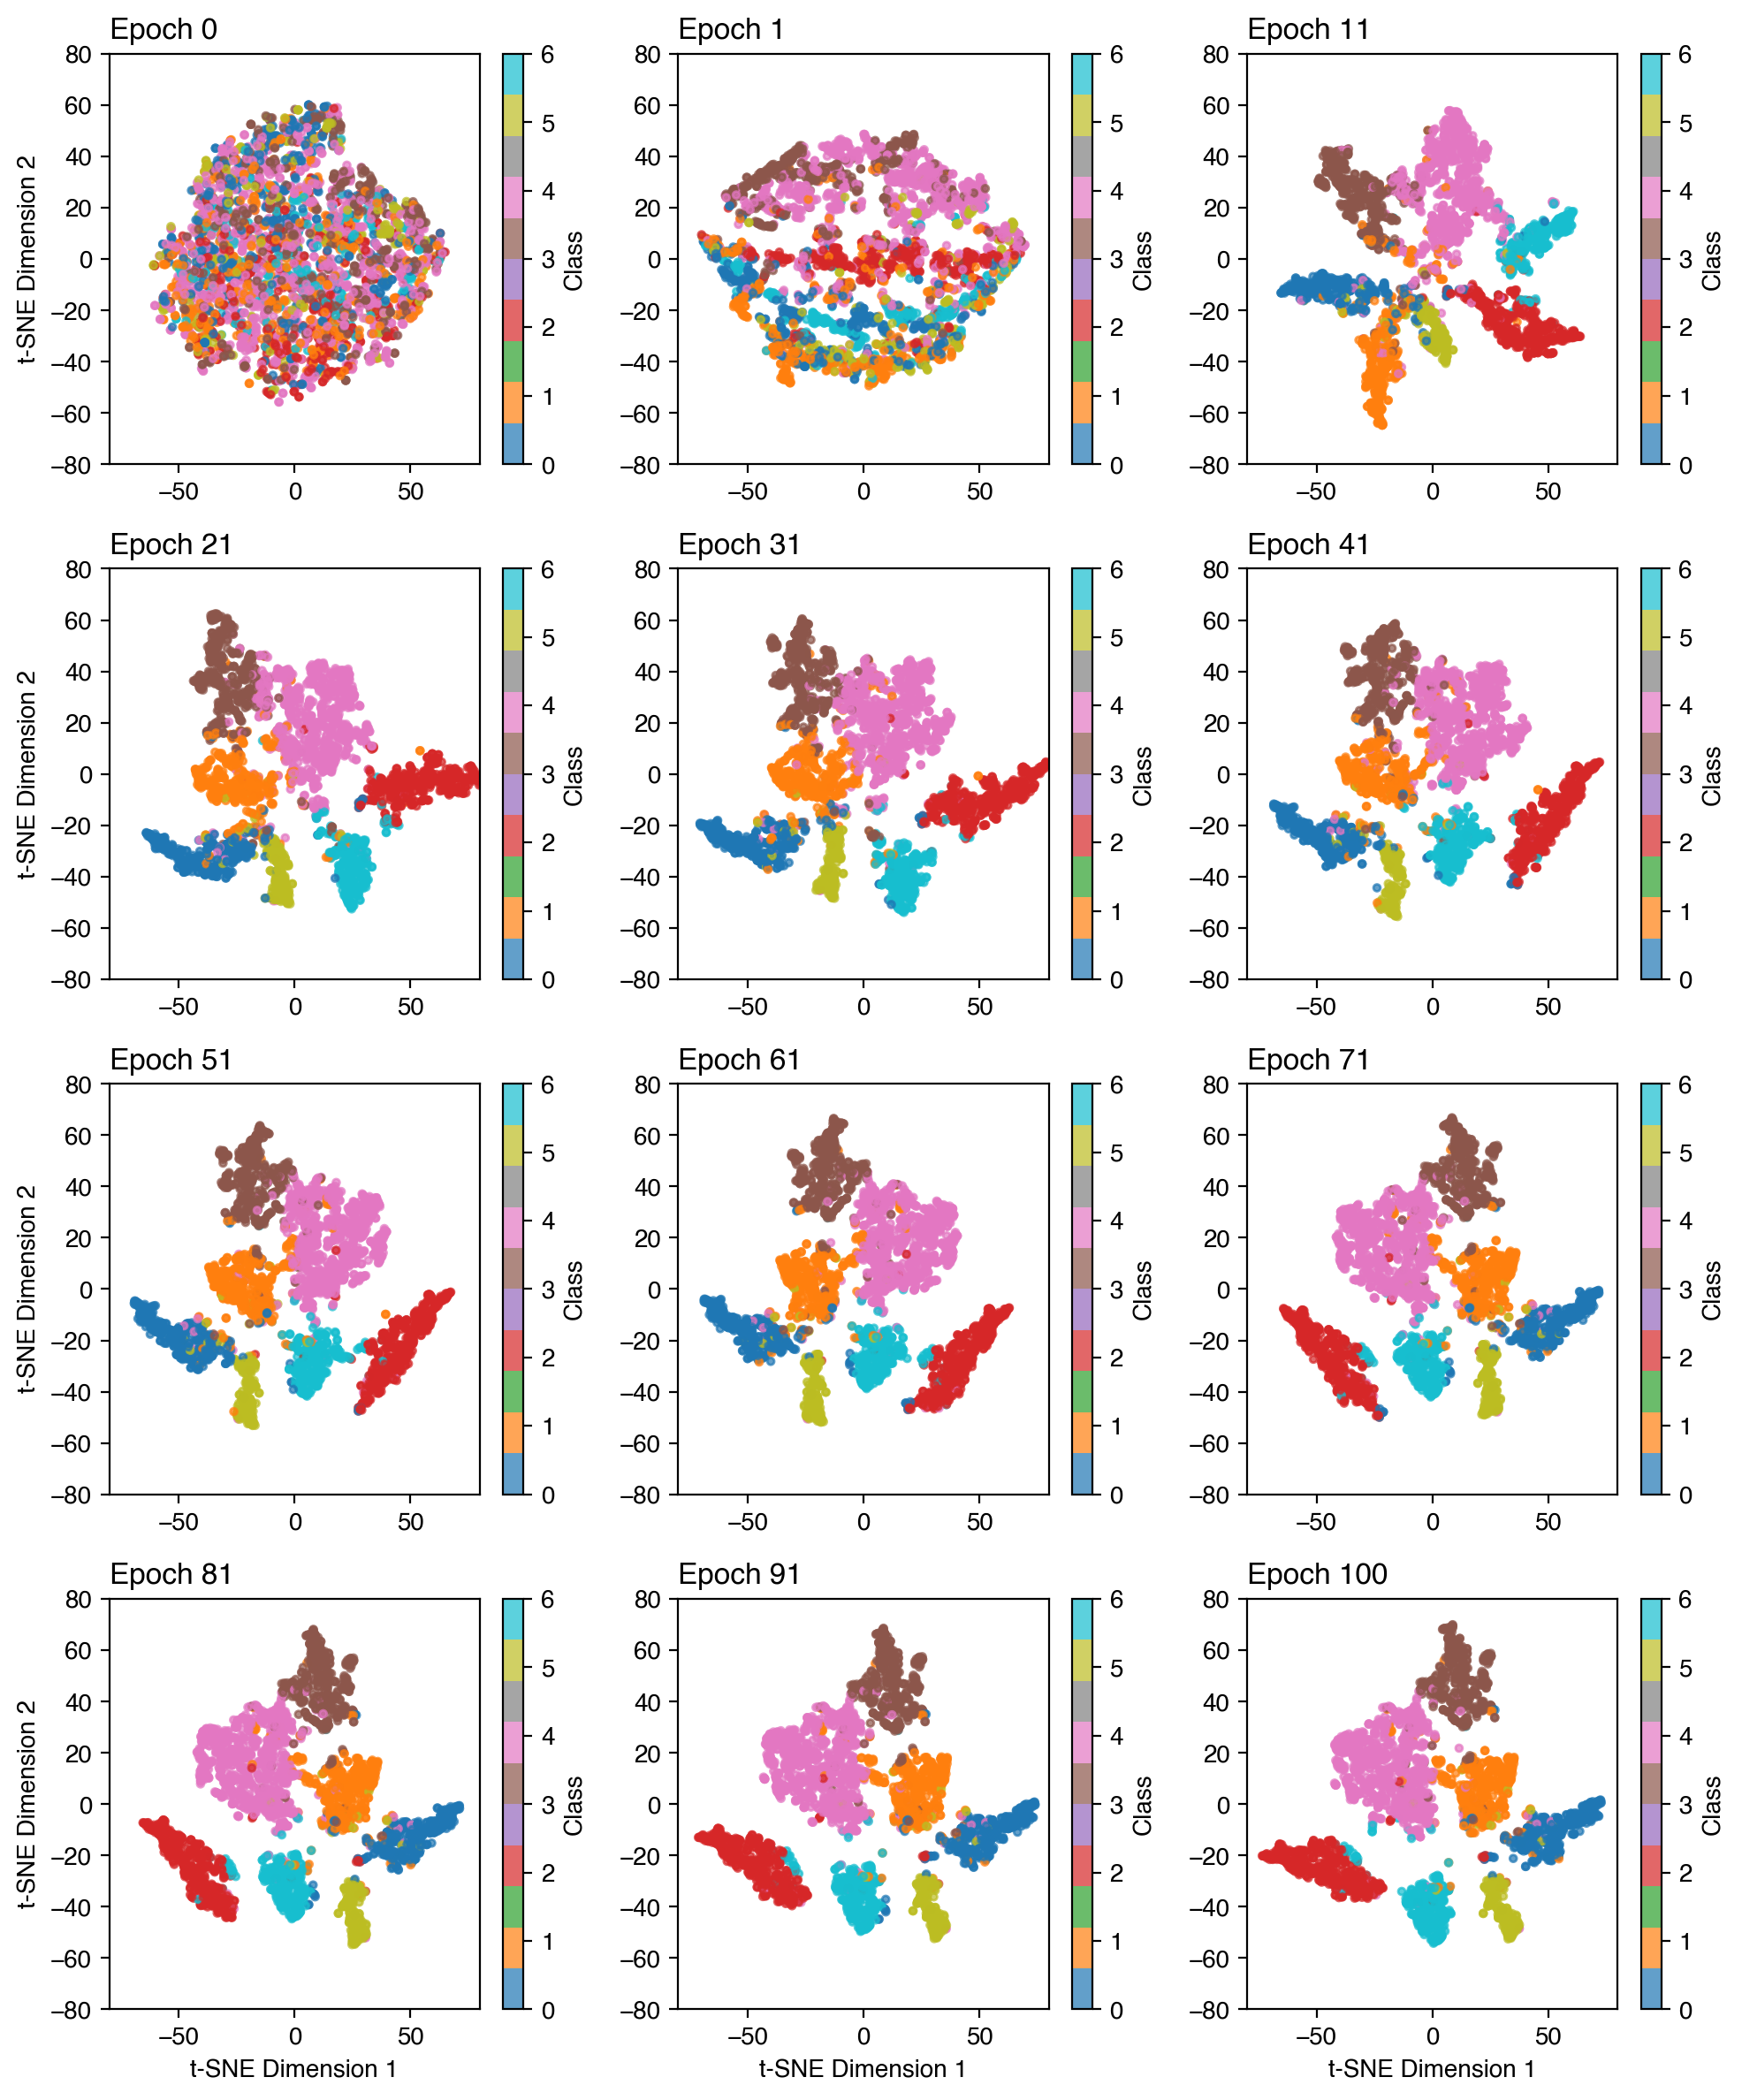

In [25]:
ncols = 3
nrows = 4
fig, ax = plt.subplots(nrows, ncols, figsize=(10,12))

axs = ax.flatten()

for idx, epoch in enumerate(checkpoint_epochs_plot):
    ax = axs[idx]
    embeddings_tsne = embeddings_tsne_dict[epoch]
    plot_embeddings(embeddings_tsne,  dataset.y.cpu().numpy(), epoch, fig=fig, ax=ax, size=8)

    # No y axis label for col 2-4
    if idx%ncols != 0:
        ax.set_ylabel("")
    
    # No x axis label for row 1-2
    if idx//ncols + 1 != nrows:
        ax.set_xlabel("")

fig.tight_layout()
plt.savefig('figure/embeddings_subplot.pdf', bbox_inches='tight')

plt.show()

### Q4(d) t-SNE animation

In [352]:
from tqdm.contrib import tenumerate

In [404]:
for idx, epoch in tenumerate(checkpoint_epochs):
    embeddings_tsne = embeddings_tsne_dict[epoch]

    fig, ax = plt.subplots(figsize=(8, 6))
    plot_embeddings(embeddings_tsne,  dataset.y.cpu().numpy(), epoch, fig=fig, ax=ax)
    # fig.savefig(f'figure/embeddings/pdf/embeddings_img{str(idx).zfill(2)}_epoch_{epoch}.pdf', bbox_inches='tight')

    # We use this PNGs to make animation in FFMPEG
    # ffmpeg -r 10 -pattern_type glob -i '*.png' -vcodec libx264 -acodec copy -pix_fmt yuv420p -vf scale=-2:1484 -r 10 output.mp4
    fig.savefig(f'figure/embeddings/png/embeddings_img{str(idx).zfill(2)}.png', bbox_inches='tight', dpi=200)

    plt.close(fig)

  0%|                                                                             | 0/101 [00:00<?, ?it/s]

100%|███████████████████████████████████████████████████████████████████| 101/101 [00:52<00:00,  1.91it/s]


<a href="https://imgur.com/a/Iqv4P4A"><video src="https://i.imgur.com/c6c39Vl.mp4" controls></a>